In [1]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Importing the modules we built 
from src.data_loader import load_and_preprocess_election_data

from src.models.bijectors import ExpBijector
from src.models.priors import compute_hierarchical_prior_log_prob
from src.models.logistics import compute_log_likelihood
from src.inference.elbo import ADVI_ELBO
from src.inference.optimizers import ADVIOptimizer
from src.evaluation.metrics import compute_predictive_metrics


Loading 1988 Election polling data...
Starting ADVI optimization for 500 iterations...
Iteration 500/500 | Negative ELBO: 1370.5193
Training complete!

Computing Bayesian Predictive Metrics...
-----------------------------------
Accuracy:               0.6253
ROC AUC:                0.6614
Log-Predictive Density: -1294.0026
-----------------------------------


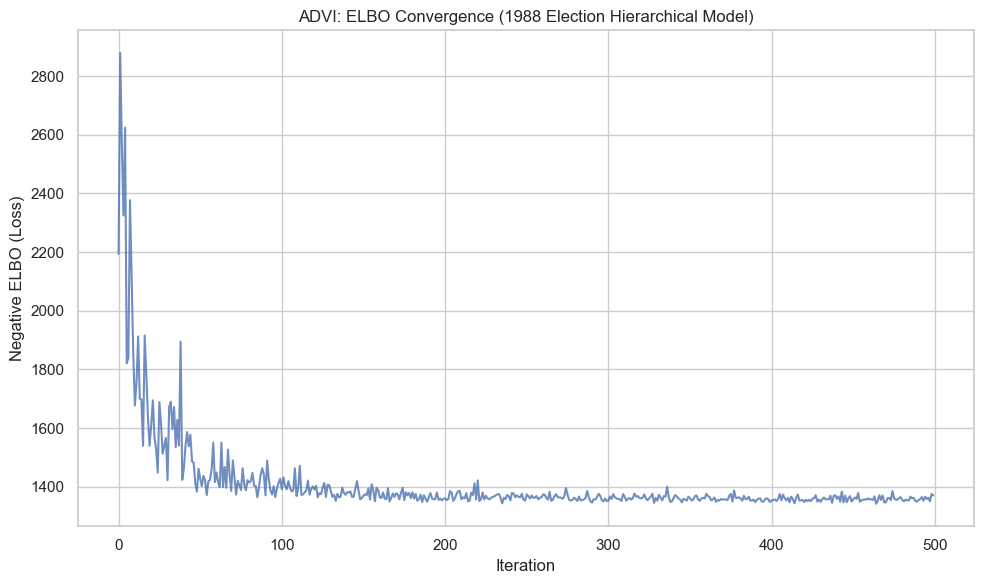

In [2]:
def main():
    # 1. Load Data
    print("Loading 1988 Election polling data...")

    X, y, state_idx, state_to_region_idx = load_and_preprocess_election_data()
    
    # Optional: Split data if you want to test predictive density later
    # X_train, y_train, state_idx_train, ... = spatial_train_test_split(X, y, state_idx)
    
    n_features = X.shape[1]
    n_states = len(torch.unique(state_idx))
    n_regions = len(torch.unique(state_to_region_idx))

    # 2. Initialize ADVI Components
    bijector = ExpBijector()
    
    # We pass the prior and likelihood functions to our ELBO calculator
    elbo_calculator = ADVI_ELBO(
        bijector=bijector,
        prior_fn=compute_hierarchical_prior_log_prob,
        likelihood_fn=compute_log_likelihood
    )
    
    # Initialize the optimizer (which holds our variational parameters phi)
    optimizer = ADVIOptimizer(
        n_features=n_features, 
        n_states=n_states, 
        n_regions=n_regions, 
        lr=0.05 # Adaptive step-size learning rate
    )

    # 3. Training Loop Configuration
    n_iterations = 500
    n_samples = 1 # S=1 as suggested in the proposal
    loss_history = []

    print(f"Starting ADVI optimization for {n_iterations} iterations...")
    
    # 4. The Execution Loop
    for iteration in range(n_iterations):
        # Perform one step of gradient ascent (minimizing negative ELBO)
        loss = optimizer.step(
            elbo_calculator=elbo_calculator,
            X=X,
            y=y,
            state_idx=state_idx,
            state_to_region_idx=state_to_region_idx,
            n_samples=n_samples
        )
        
        loss_history.append(loss)
        
        # Print progress
        if (iteration + 1) % 500 == 0:
            print(f"Iteration {iteration + 1}/{n_iterations} | Negative ELBO: {loss:.4f}")

    print("Training complete!")

    # 5. Evaluation Block
    print("\nComputing Bayesian Predictive Metrics...")
    accuracy, auc, lpd = compute_predictive_metrics(
        X=X, 
        y=y, 
        state_idx=state_idx, 
        vp=optimizer.vp, 
        n_samples=1000  # Draw 1000 samples for stable Bayesian averaging
    )
    
    print("-" * 35)
    print(f"Accuracy:               {accuracy:.4f}")
    print(f"ROC AUC:                {auc:.4f}")
    print(f"Log-Predictive Density: {lpd:.4f}")
    print("-" * 35)

    # 5. Plotting ELBO Convergence
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(10, 6))
    plt.plot(loss_history, color='b', alpha=0.8)
    plt.title("ADVI: ELBO Convergence (1988 Election Hierarchical Model)")
    plt.xlabel("Iteration")
    plt.ylabel("Negative ELBO (Loss)")
    plt.tight_layout()
    plt.show()



    # Ensure PyTorch uses float64 for better numerical stability during VI
    torch.set_default_dtype(torch.float64)

main()